In [50]:
# Ensure project root is on path and cwd when running from EDA/notebooks/
import os
import sys
import importlib

cwd = os.path.abspath(os.getcwd())
if os.path.basename(cwd) == "notebooks" and os.path.basename(os.path.dirname(cwd)) == "EDA":
    root = os.path.dirname(os.path.dirname(cwd))
    os.chdir(root)
    sys.path.insert(0, root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import Image, display


In [51]:
import EDA.eda_utils as eda_utils
importlib.reload(eda_utils)
from EDA.eda_utils import *

set_plots_dir("EDA/output/brand_sentiment")
set_report_path("brand_eda_report.txt")
reset_report()
write_section("Brand Sentiment Dataset EDA")
write_report("This report captures a focused NLP EDA for the Twitter brand sentiment training dataset.")

df = load_data("EDA/datasets/twitter-sentiment/Dataset - Train.csv")
text_col = "tweet_text"
entity_col = "emotion_in_tweet_is_directed_at"
sentiment_col = "is_there_an_emotion_directed_at_a_brand_or_product"


# Brand Sentiment Dataset EDA

This notebook is intentionally focused on the analyses that most directly inform NLP sentiment modeling. All official outputs are saved under `EDA/output/`.


## Dataset Overview

We begin with the dataset shape, columns, and dataframe info so the later modeling-oriented checks have clear context.


In [52]:
write_section("Dataset Overview")
dataset_overview(df)
display(df.head())


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


## Data Quality Checks

Missing values and duplicates are directly relevant to model quality and train/evaluation cleanliness.


In [53]:
write_section("Data Quality Checks")
missing_value_summary(df)
duplicate_stats = duplicate_summary(df, text_col)
display(df.isnull().sum().to_frame(name="missing_values"))
display(duplicate_stats)


,missing_values
tweet_text,1
emotion_in_tweet_is_directed_at,5298
is_there_an_emotion_directed_at_a_brand_or_product,0


,metric,value
0,duplicate_rows,22.0000
1,duplicate_texts,27.0000
2,unique_text_ratio,0.9967


## Target Variable Analysis

The class distribution is a key modeling signal because it exposes imbalance and rare labels that may need special handling.


,count,percentage
is_there_an_emotion_directed_at_a_brand_or_product,,
No emotion toward brand or product,5389,62.74
Positive emotion,2672,31.11
Negative emotion,519,6.04
I can't tell,9,0.10


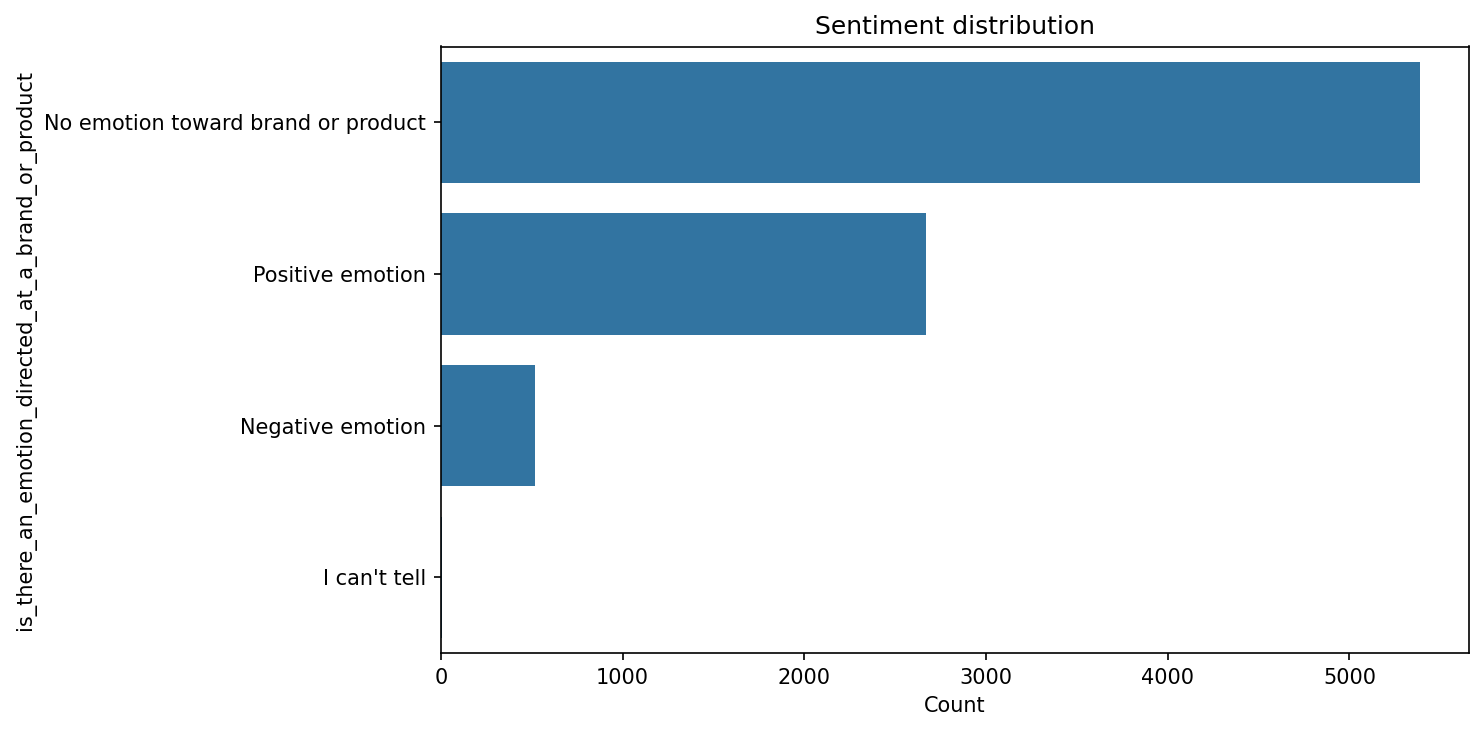

"'I can't tell' accounts for only 0.10% of rows, so it is extremely rare. Consider dropping it or merging it into a broader neutral or uncertain class before modeling."

In [54]:
write_section("Target Variable Analysis")
sentiment_plot_path = sentiment_distribution(df, sentiment_col)
label_summary, rare_class_note = label_cleanup_analysis(df, sentiment_col)
display(label_summary)
display(Image(filename=sentiment_plot_path))
rare_class_note


## Text Statistics

Tweet length and compact vocabulary statistics help inform truncation, filtering, and representation choices without adding noisy low-value plots.


,tweet_text,text_length,word_count
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,127,23
1,@jessedee Know about @fludapp ? Awesome iPad/i...,139,22
2,@swonderlin Can not wait for #iPad 2 also. The...,79,15
3,@sxsw I hope this year's festival isn't as cra...,82,15
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,131,17
5,@teachntech00 New iPad Apps For #SpeechTherapy...,140,18
6,NaN,0,0
7,"#SXSW is just starting, #CTIA is around the co...",138,28
8,Beautifully smart and simple idea RT @madebyma...,129,17
9,Counting down the days to #sxsw plus strong Ca...,88,16


,mean,median,std
is_there_an_emotion_directed_at_a_brand_or_product,,,
I can't tell,113.333333,119.0,22.527761
Negative emotion,108.915222,114.0,27.544428
No emotion toward brand or product,104.131193,108.0,27.140292
Positive emotion,105.457710,110.0,27.227519


,metric,value
0,token_count,131458.0000
1,vocabulary_size,8363.0000
2,type_token_ratio,0.0636


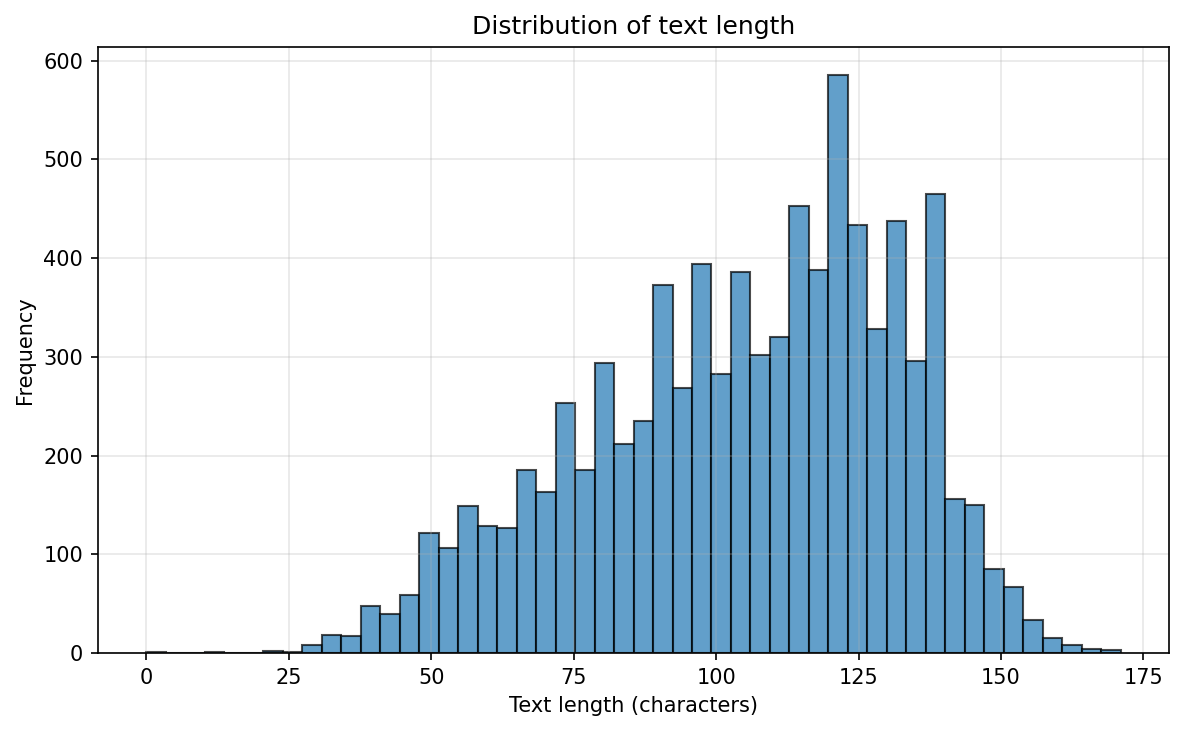

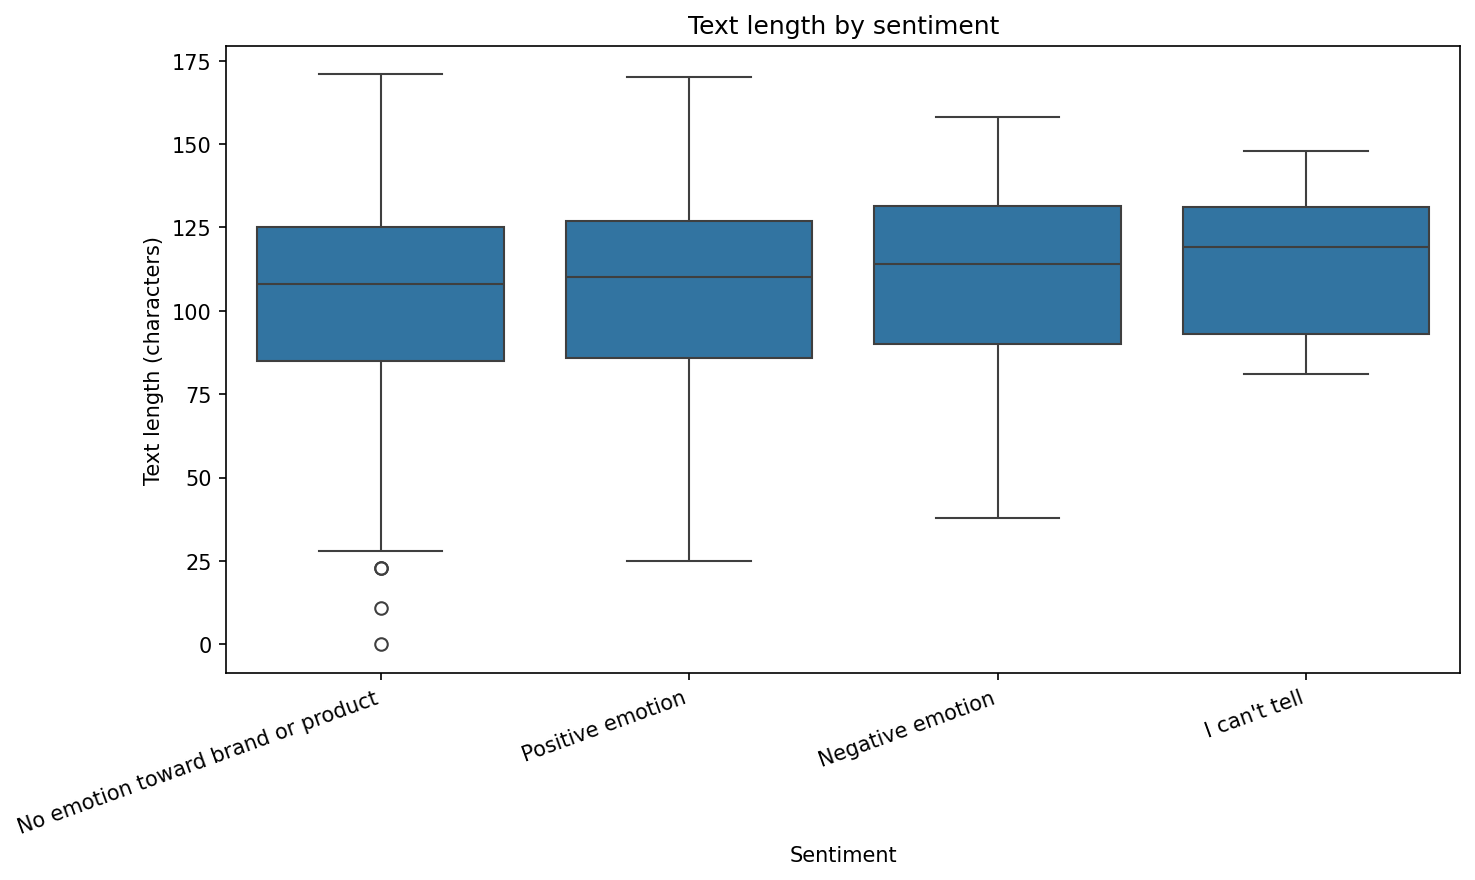

In [55]:
write_section("Text Statistics")
text_length_features(df, text_col)
text_length_plot_path = plot_text_length_distribution(df, text_col)
class_length_summary, text_length_by_sentiment_plot_path = class_wise_text_length_analysis(df, text_col, sentiment_col)
tokens = clean_and_tokenize(df, text_col)
vocab_summary = vocabulary_statistics(tokens)
display(df[[text_col, "text_length", "word_count"]].head(10))
display(class_length_summary)
display(vocab_summary)
display(Image(filename=text_length_plot_path))
display(Image(filename=text_length_by_sentiment_plot_path))


## Brand / Entity Analysis

Brand and product mentions add useful context about which entities are discussed most and how sentiment differs across them.


,entity,count
0,iPad,946
1,Apple,661
2,iPad or iPhone App,470
3,Google,430
4,iPhone,297
5,Other Google product or service,293
6,Android App,81
7,Android,78
8,Other Apple product or service,35


is_there_an_emotion_directed_at_a_brand_or_product,I can't tell,Negative emotion,No emotion toward brand or product,Positive emotion
emotion_in_tweet_is_directed_at,,,,
iPad,4,125,24,793
Apple,2,95,21,543
iPad or iPhone App,0,63,10,397
Google,1,68,15,346
iPhone,1,103,9,184
Other Google product or service,1,47,9,236
Android App,0,8,1,72
Android,0,8,1,69
Other Apple product or service,0,2,1,32


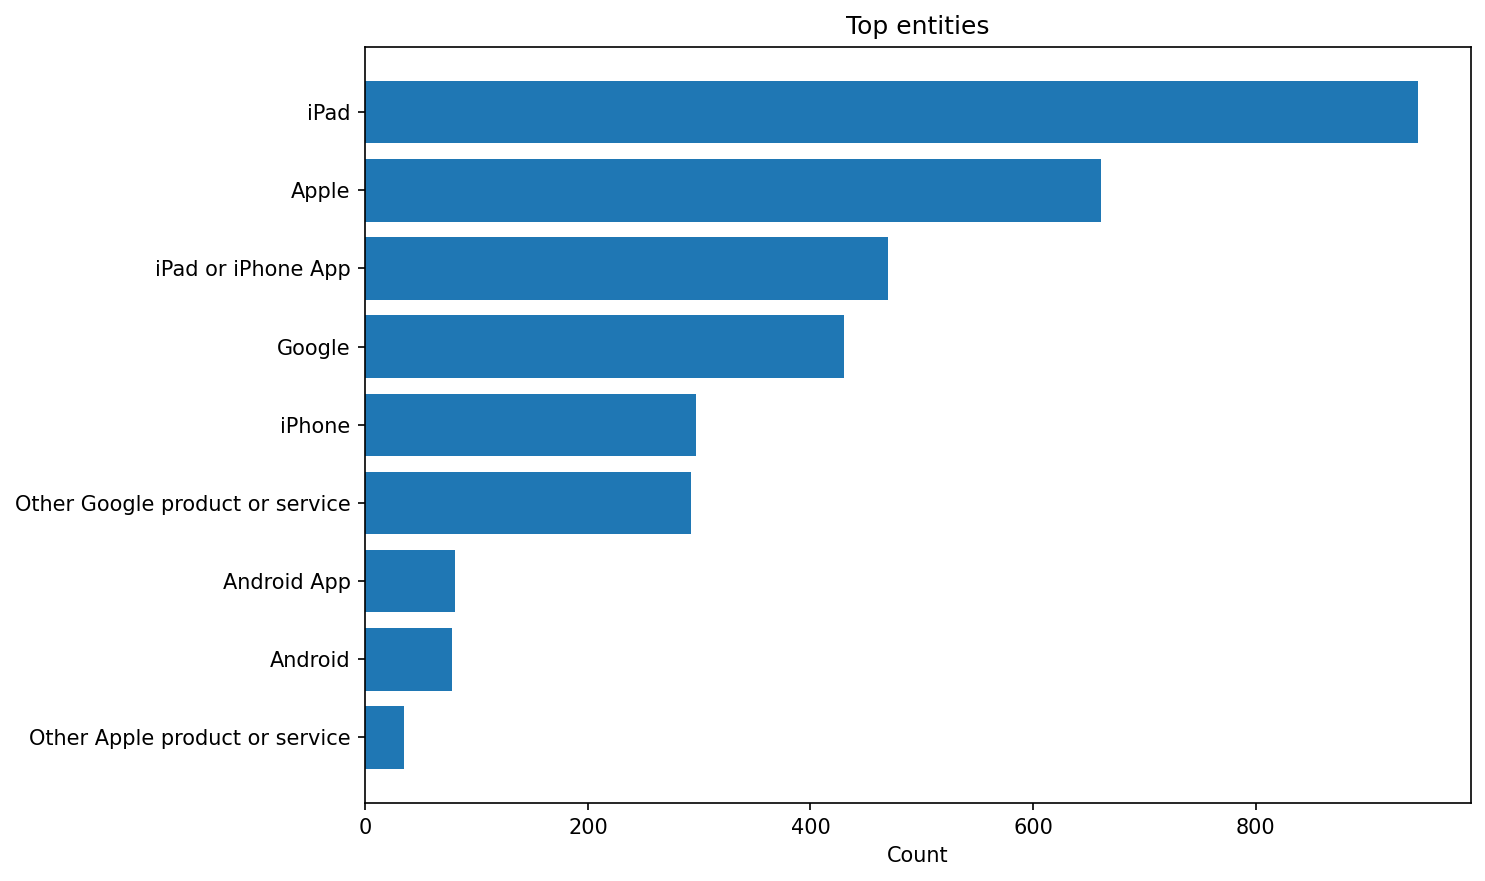

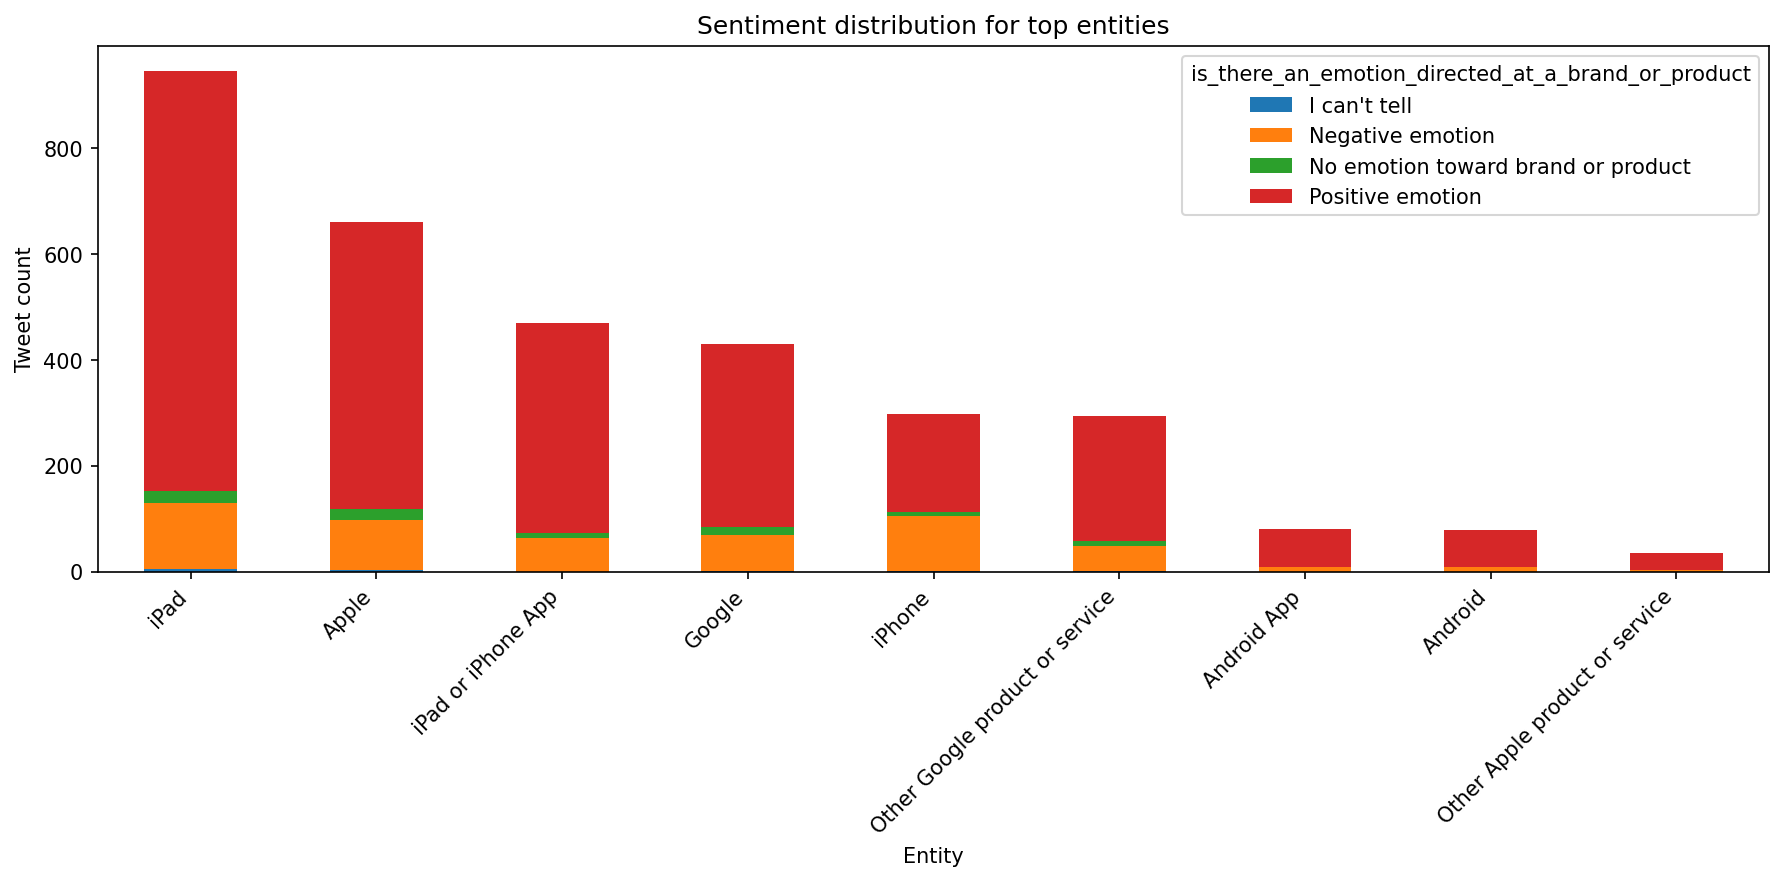

In [56]:
write_section("Brand / Entity Analysis")
entity_summary, top_entities_plot_path = entity_column_analysis(df, entity_col)
entity_sentiment_table, sentiment_by_entity_plot_path = sentiment_by_entity(df, entity_col, sentiment_col)
display(entity_summary)
display(entity_sentiment_table)
display(Image(filename=top_entities_plot_path))
display(Image(filename=sentiment_by_entity_plot_path))


## Hashtag Analysis

Hashtags often carry event and brand context in Twitter data, so they are worth keeping as a focused source of domain signal.


,count,proportion
contains_hashtag,8582,0.999185
contains_mention,4656,0.542089
contains_link,4008,0.466643
contains_rt,2530,0.294563


,count
#sxsw,8613
#apple,395
#google,311
#sxswi,307
#ipad2,279
#ipad,252
#iphone,247
#android,126
#austin,107
#circles,93


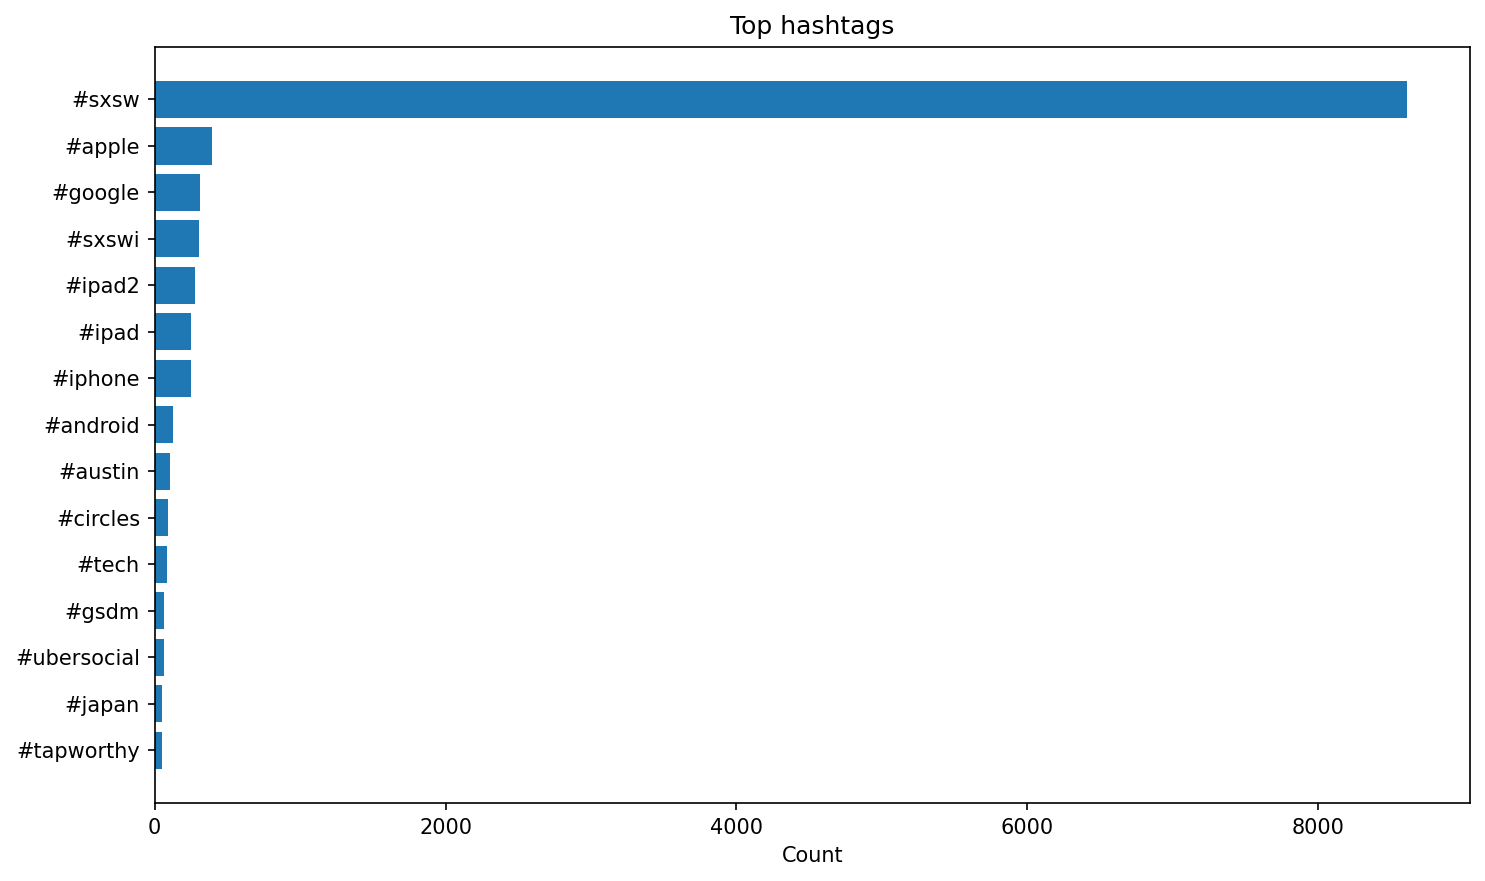

In [57]:
write_section("Hashtag Analysis")
hashtag_summary, top_hashtags, top_hashtags_plot_path = hashtag_mention_link_analysis(df, text_col)
display(hashtag_summary)
display(top_hashtags.to_frame(name="count"))
display(Image(filename=top_hashtags_plot_path))


## TF-IDF Feature Diagnostics

TF-IDF sparsity and active-feature counts help judge whether sparse vector models are likely to behave well on this dataset.


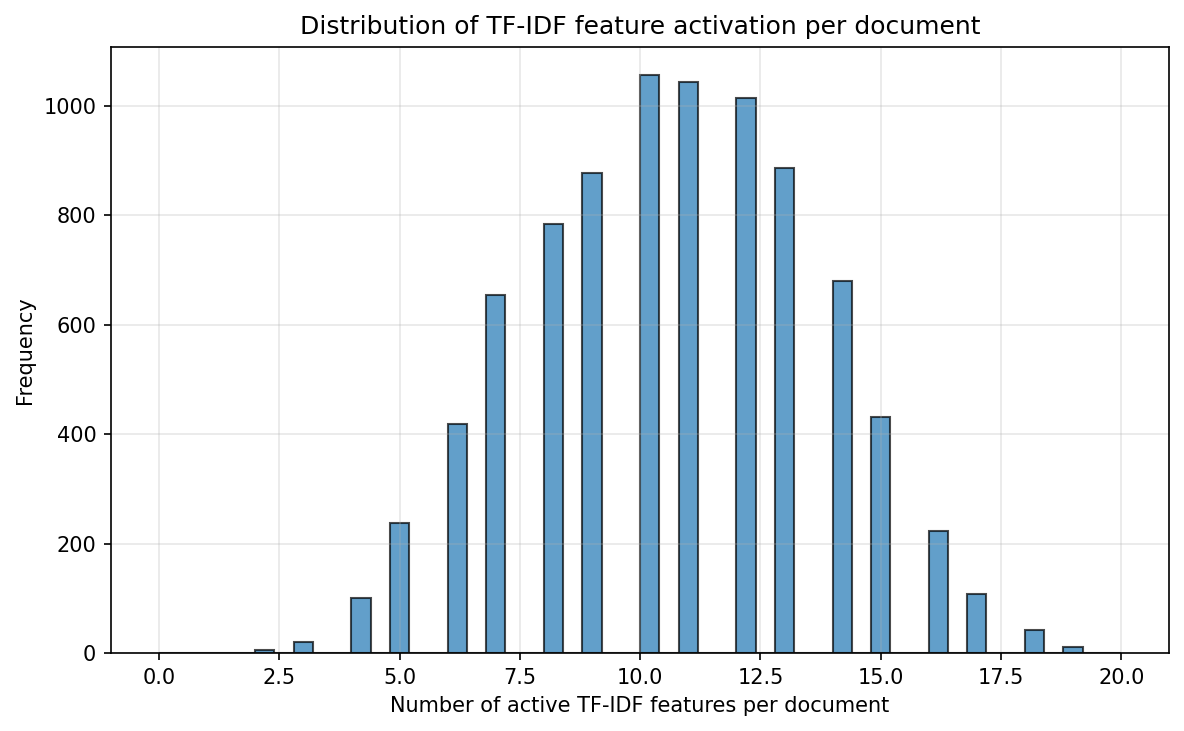

In [58]:
write_section("TF-IDF Feature Diagnostics")
nnz_per_doc = tfidf_diagnostics(df, text_col)
tfidf_plot_path = plot_tfidf_feature_distribution(nnz_per_doc)
display(Image(filename=tfidf_plot_path))


## Feature Correlation

A small engineered feature set helps summarize how length, stopwords, casing, punctuation, and digits relate to each other.


,text_length,word_count,stopword_ratio,uppercase_ratio,exclamation_count,question_count,digit_count
text_length,1.000,0.896,0.052,-0.184,0.061,0.025,0.064
word_count,0.896,1.000,0.276,-0.174,0.085,0.038,0.074
stopword_ratio,0.052,0.276,1.000,-0.185,0.031,0.083,-0.169
uppercase_ratio,-0.184,-0.174,-0.185,1.000,0.044,-0.006,0.017
exclamation_count,0.061,0.085,0.031,0.044,1.000,-0.024,-0.000
question_count,0.025,0.038,0.083,-0.006,-0.024,1.000,-0.032
digit_count,0.064,0.074,-0.169,0.017,-0.000,-0.032,1.000


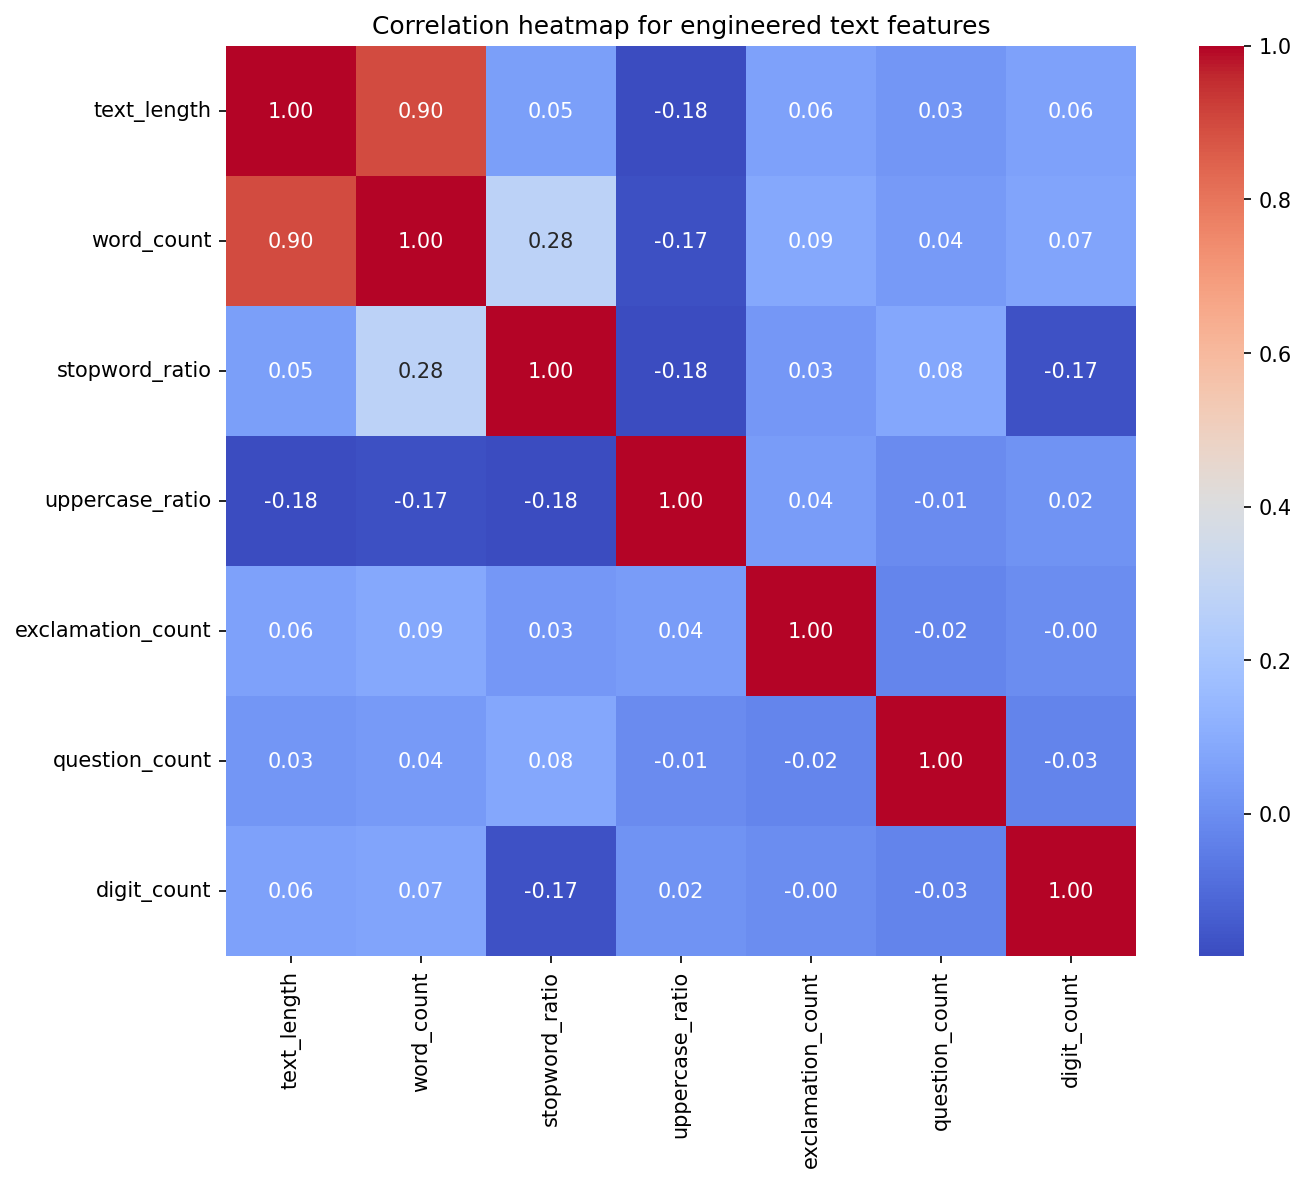

'EDA/output/text/eda_report.txt'

In [59]:
write_section("Feature Correlation")
correlation_matrix, correlation_plot_path = feature_correlation_analysis(df, text_col)
display(correlation_matrix)
display(Image(filename=correlation_plot_path))

REPORT_PATH
